**1. Import Libraries and Load MNIST Dataset**

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print(f"Original dataset shape: X = {X.shape}, y = {y.shape}")

Original dataset shape: X = (70000, 784), y = (70000,)


Load the raw MNIST dataset. Labels are converted to integers for easier handling.

**2. Filter and Sample Data for Binary Classification (0 vs 8)**

In [35]:
# Keep only digits 0 and 8
mask = (y == 0) | (y == 8)
X_filtered = X[mask]
y_filtered = y[mask]

# Balanced sampling: 3000 samples per class
np.random.seed(42)
idx_0 = np.where(y_filtered == 0)[0]
idx_8 = np.where(y_filtered == 8)[0]

idx_0_sample = np.random.choice(idx_0, 3000, replace=False)
idx_8_sample = np.random.choice(idx_8, 3000, replace=False)

selected_idx = np.concatenate([idx_0_sample, idx_8_sample])
np.random.shuffle(selected_idx)

X_selected = X_filtered[selected_idx]
y_selected = y_filtered[selected_idx]

print(f"Filtered and sampled data shape: X = {X_selected.shape}, y = {y_selected.shape}")
print(f"Class distribution: 0 -> {np.sum(y_selected == 0)}, 8 -> {np.sum(y_selected == 8)}")

Filtered and sampled data shape: X = (6000, 784), y = (6000,)
Class distribution: 0 -> 3000, 8 -> 3000


**3. Visualization for Sample Images**

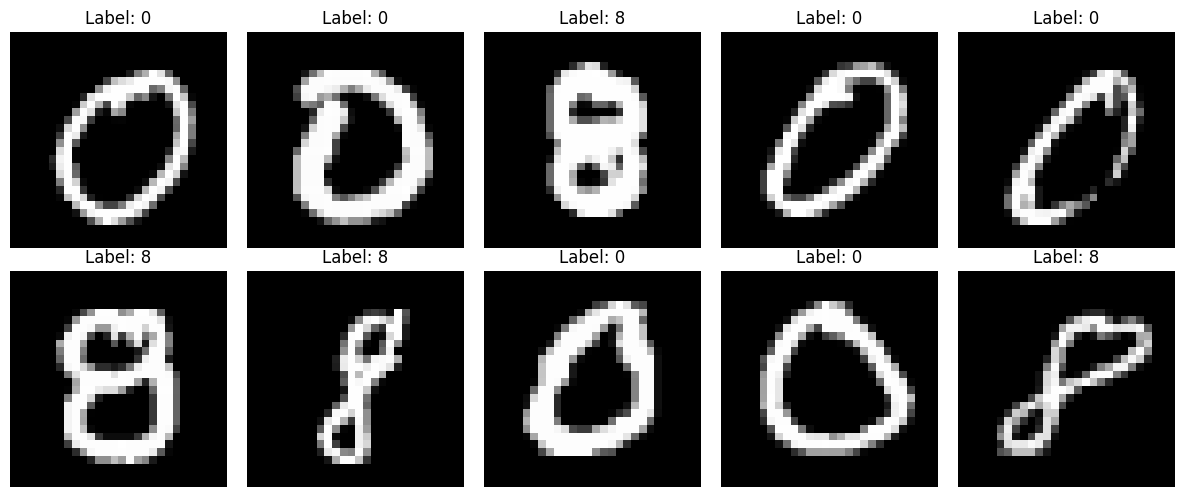

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    img = X_selected[i].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Label: {y_selected[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**4. 2D Visualization via PCA**

Variance explained by 2 PCs: 0.2806 (28.06%)


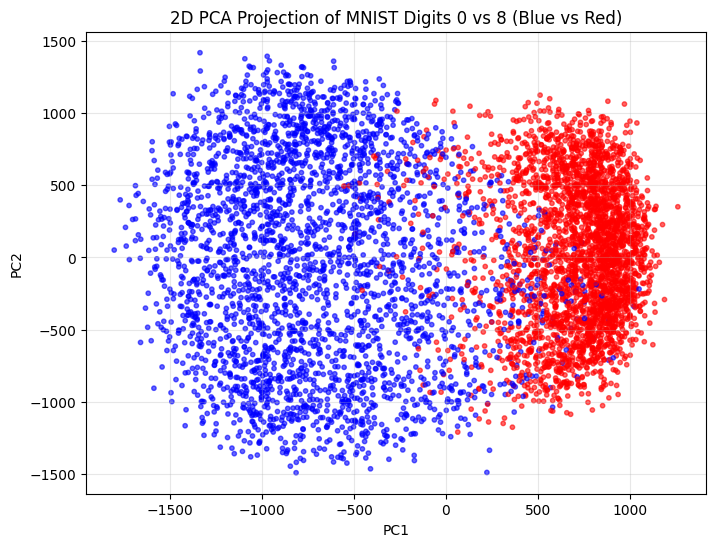

In [37]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_selected)

explained_var_2d = np.sum(pca_2d.explained_variance_ratio_)
print(f"Variance explained by 2 PCs: {explained_var_2d:.4f} ({explained_var_2d*100:.2f}%)")

plt.figure(figsize=(8, 6))
colors = ['blue' if label == 0 else 'red' for label in y_selected]
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors, alpha=0.6, s=10)
plt.title('2D PCA Projection of MNIST Digits 0 vs 8 (Blue vs Red)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

Applies PCA to project the high-dimensional (784D) data into 2D for a scatter plot. This reveals class separability: clusters should show some overlap due to handwriting noise, but general separation indicates the data is linearly classifiable to some extent.

**5.Cross Validation Comparison: Original vs PCA 0.9**

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model A: Original pixel space
pipeline_original = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=10000,
        random_state=42
    ))
])

# Model B: PCA feature space
pipeline_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.9, random_state=42)),
    ("logreg", LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=10000,
        random_state=42
    ))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

results_original = cross_validate(
    pipeline_original,
    X_selected,
    y_selected,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

results_pca = cross_validate(
    pipeline_pca,
    X_selected,
    y_selected,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Cross-validation results")
print("-" * 60)

print("Original Pixels + L1 Logistic")
print(f"Mean Accuracy : {results_original['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {results_original['test_precision'].mean():.4f}")
print(f"Mean Recall   : {results_original['test_recall'].mean():.4f}")
print(f"Mean F1-score : {results_original['test_f1'].mean():.4f}")
print(f"Mean Fit Time : {results_original['fit_time'].mean():.4f} sec")
print(f"Mean Score Time: {results_original['score_time'].mean():.4f} sec")

print("\nPCA + L1 Logistic")
print(f"Mean Accuracy : {results_pca['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {results_pca['test_precision'].mean():.4f}")
print(f"Mean Recall   : {results_pca['test_recall'].mean():.4f}")
print(f"Mean F1-score : {results_pca['test_f1'].mean():.4f}")
print(f"Mean Fit Time : {results_pca['fit_time'].mean():.4f} sec")
print(f"Mean Score Time: {results_pca['score_time'].mean():.4f} sec")

Cross-validation results
------------------------------------------------------------
Original Pixels + L1 Logistic
Mean Accuracy : 0.9885
Mean Precision: 0.9885
Mean Recall   : 0.9885
Mean F1-score : 0.9885
Mean Fit Time : 0.3269 sec
Mean Score Time: 0.0129 sec

PCA + L1 Logistic
Mean Accuracy : 0.9877
Mean Precision: 0.9877
Mean Recall   : 0.9877
Mean F1-score : 0.9877
Mean Fit Time : 0.7426 sec
Mean Score Time: 0.0152 sec


**6.Cross Validation Results**

In [39]:
comparison_df = pd.DataFrame({
    "Model": [
        "Original Pixels + L1 Logistic",
        "PCA + L1 Logistic"
    ],
    "Mean Accuracy": [
        results_original["test_accuracy"].mean(),
        results_pca["test_accuracy"].mean()
    ],
    "Mean Precision": [
        results_original["test_precision"].mean(),
        results_pca["test_precision"].mean()
    ],
    "Mean Recall": [
        results_original["test_recall"].mean(),
        results_pca["test_recall"].mean()
    ],
    "Mean F1": [
        results_original["test_f1"].mean(),
        results_pca["test_f1"].mean()
    ],
    "Mean Fit Time (s)": [
        results_original["fit_time"].mean(),
        results_pca["fit_time"].mean()
    ],
    "Mean Score Time (s)": [
        results_original["score_time"].mean(),
        results_pca["score_time"].mean()
    ]
})

comparison_df = comparison_df.sort_values(by="Mean Accuracy", ascending=False)
comparison_df

,Model,Mean Accuracy,Mean Precision,Mean Recall,Mean F1,Mean Fit Time (s),Mean Score Time (s)
0,Original Pixels + L1 Logistic,0.988500,0.988516,0.988500,0.988500,0.326887,0.01290
1,PCA + L1 Logistic,0.987667,0.987692,0.987667,0.987666,0.742621,0.01518


L1-regularized logistic regression trained on the original pixel space achieves strong performance, with an average accuracy of approximately 0.99 across all evaluation metrics while maintaining a relatively short training time. In comparison, applying PCA before logistic regression results in slightly lower accuracy and roughly doubles the model fitting time. This suggests that, for this binary MNIST classification task, the original pixel representation combined with L1 regularization is both more accurate and more computationally efficient than the PCA-transformed feature space.

**7.Evaluation**

Original Pixels + L1 Logistic
Accuracy: 0.9885

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3000
           8       0.99      0.99      0.99      3000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



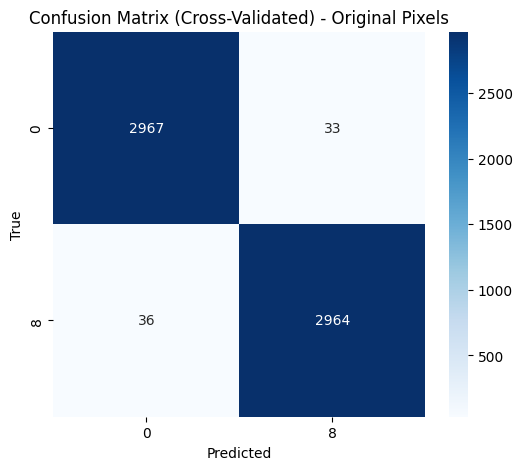

In [40]:
# For original pixel space
y_pred_cv_original = cross_val_predict(
    pipeline_original,
    X_selected,
    y_selected,
    cv=cv
)

print("Original Pixels + L1 Logistic")
print(f"Accuracy: {accuracy_score(y_selected, y_pred_cv_original):.4f}")
print("\nClassification Report:")
print(classification_report(y_selected, y_pred_cv_original, target_names=["0", "8"]))

cm_original = confusion_matrix(y_selected, y_pred_cv_original)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '8'], yticklabels=['0', '8'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Cross-Validated) - Original Pixels')
plt.show()

Out of 6000 total samples evaluated through cross-validation, only 69 misclassifications occur, corresponding to an error rate of approximately 1.15% and an overall accuracy of $5931/6000 \approx 98.85\%$. The confusion matrix reveals near-symmetric errors between the two classes: 33 instances of digit 0 misclassified as 8 and 36 instances of digit 8 misclassified as 0. These mistakes likely arise from ambiguous handwritten shapes, such as elongated zeros that resemble an 8 or simplified eights that appear similar to a zero. Despite these few errors, the model demonstrates strong discriminative capability. The high accuracy combined with L1-induced sparsity indicates that the classifier successfully focuses on informative pixel regions corresponding to digit structure while suppressing irrelevant background pixels.

PCA + L1 Logistic
Accuracy: 0.9877

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3000
           8       0.99      0.99      0.99      3000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



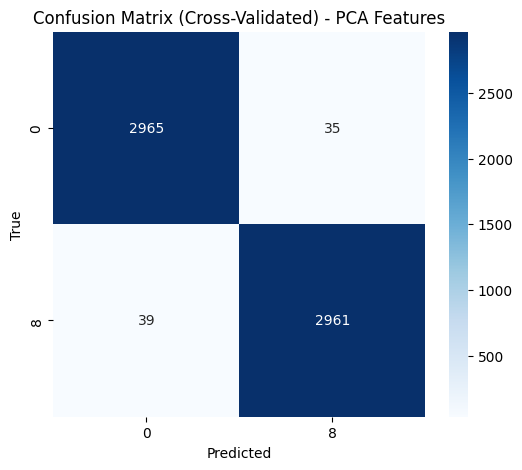

In [41]:
# For PCA 0.9
y_pred_cv_pca = cross_val_predict(
    pipeline_pca,
    X_selected,
    y_selected,
    cv=cv
)

print("PCA + L1 Logistic")
print(f"Accuracy: {accuracy_score(y_selected, y_pred_cv_pca):.4f}")
print("\nClassification Report:")
print(classification_report(y_selected, y_pred_cv_pca, target_names=["0", "8"]))

cm_pca = confusion_matrix(y_selected, y_pred_cv_pca)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '8'], yticklabels=['0', '8'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Cross-Validated) - PCA Features')
plt.show()

For the PCA-transformed feature space, cross-validation yields 74 misclassifications out of 6000 samples, corresponding to an error rate of approximately 1.23% and an overall accuracy of $5926/6000 \approx 98.77\%$. The confusion matrix again shows a balanced distribution of errors, with 35 zeros misclassified as eights and 39 eights misclassified as zeros. Compared to the original pixel-space model, the PCA representation produces slightly more misclassifications. This is expected because dimensionality reduction compresses the original 784-dimensional feature space into a smaller set of principal components, inevitably discarding some fine-grained pixel information. While the PCA-based model remains highly accurate, the results suggest that the original pixel representation preserves discriminative features more effectively for this binary classification task.

**8. Separate Training for Original Space**

In [42]:
pipeline_original.fit(X_selected, y_selected)

final_logreg_original = pipeline_original.named_steps["logreg"]
coef_original = final_logreg_original.coef_[0]

num_nonzero = np.sum(coef_original != 0)
total_weights = len(coef_original)
sparsity_pct = 100 * num_nonzero / total_weights

print("Final model trained on full original dataset")
print(f"Training completed in {final_logreg_original.n_iter_[0]} iterations.")
print(f"Sparsity: {num_nonzero} non-zero weights out of {total_weights} ({sparsity_pct:.1f}%)")

Final model trained on full original dataset
Training completed in 12 iterations.
Sparsity: 195 non-zero weights out of 784 (24.9%)


L1 induces sparsity (many zero weights), which is visualized in the sparsity printout—expect ~10-30% non-zero features for MNIST.

**9. Heatmap of Relevant Features**

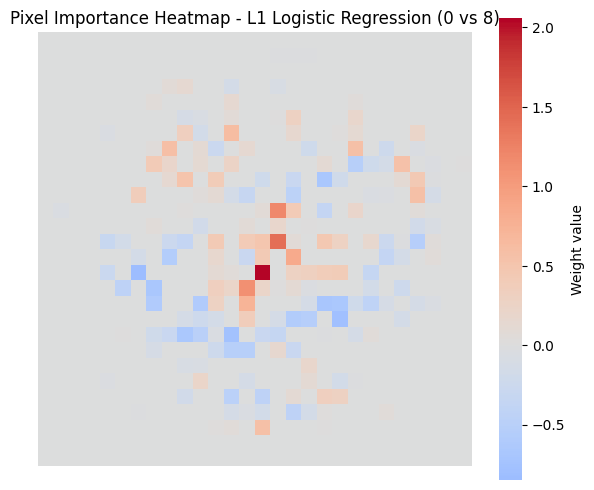

In [43]:
# For original pixel space, reshape coefficients to 28x28 for heatmap
coef_img = coef_original.reshape(28, 28)

plt.figure(figsize=(7, 6))
sns.heatmap(
    coef_img,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Weight value"}
)
plt.title("Pixel Importance Heatmap - L1 Logistic Regression (0 vs 8)")
plt.xticks([])
plt.yticks([])
plt.show()

The heatmap visualizes the learned coefficient vector of the L1-regularized logistic regression model reshaped into the original 28×28 pixel grid. Each pixel’s color represents the magnitude and sign of its weight in the decision boundary between digits 0 and 8. Positive weights (red regions) increase the likelihood of predicting digit 8, while negative weights (blue regions) indicate the prediction shifts toward digit 0.

The sparse pattern reflects the effect of L1 regularization, which drives many coefficients toward zero and retains only informative pixels. Most high-magnitude weights are concentrated around the central stroke (indicating digits 8) and outer loop regions (representing the loop of digits 0). Pixels in the background or less informative areas are suppressed, indicating that the model successfully focuses on discriminative regions of the digit while ignoring irrelevant noise.

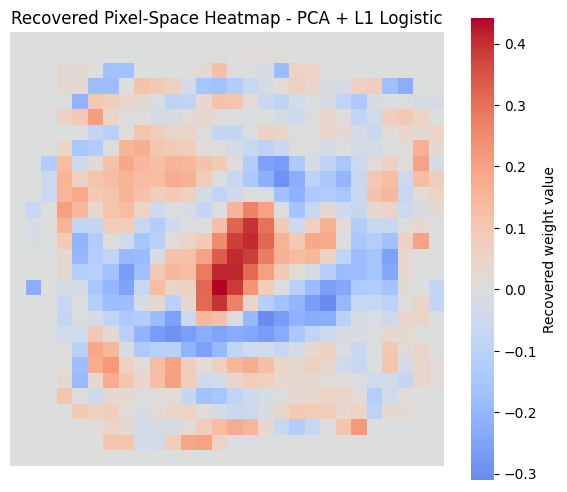

In [ ]:
# For PCA 0.9
pipeline_pca.fit(X_selected, y_selected)

final_pca = pipeline_pca.named_steps["pca"]
final_logreg_pca = pipeline_pca.named_steps["logreg"]

coef_pca = final_logreg_pca.coef_[0]
coef_pca_back = final_pca.inverse_transform(coef_pca) # convert back to original space
coef_pca_img = coef_pca_back.reshape(28, 28)

plt.figure(figsize=(7, 6))
sns.heatmap(
    coef_pca_img,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Recovered weight value"}
)
plt.title("Recovered Pixel-Space Heatmap - PCA + L1 Logistic")
plt.xticks([])
plt.yticks([])
plt.show()

This heatmap represents the recovered pixel-space coefficients from the logistic regression model trained on PCA-transformed features. Compared to the original pixel-space model, the weight distribution appears more diffuse, reflecting the nature of PCA components as linear combinations of many pixels. While the model still highlights key structures of the digits, particularly the central vertical strokes and loop areas, it spreads importance across broader regions rather than isolating specific pixels. This illustrates the tradeoff of PCA: while dimensionality reduction can compress information efficiently, it also blends pixel-level contributions, reducing interpretability relative to the original sparse model.

**10. Misclassifications from Cross Validation**

Number of misclassifications (Original Pixels): 69 / 6000


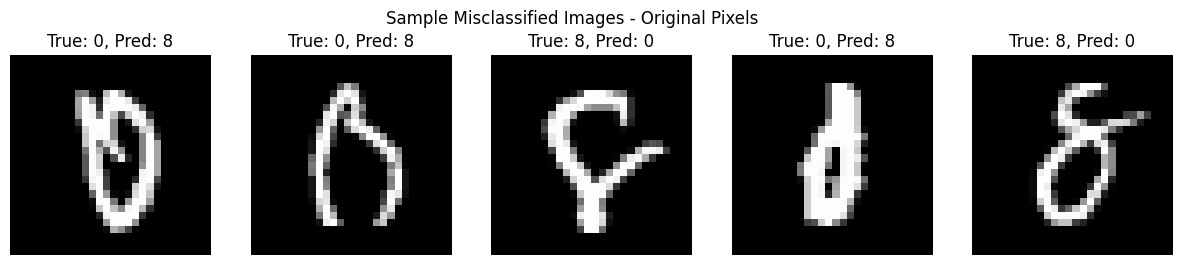

In [45]:
# For original pixel space
mis_idx_original = np.where(y_pred_cv_original != y_selected)[0]

print(f"Number of misclassifications (Original Pixels): {len(mis_idx_original)} / {len(y_selected)}")

if len(mis_idx_original) > 0:
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, idx in enumerate(mis_idx_original[:5]):
        axes[i].imshow(X_selected[idx].reshape(28, 28), cmap='gray')
        axes[i].set_title(f"True: {y_selected[idx]}, Pred: {y_pred_cv_original[idx]}")
        axes[i].axis('off')
    plt.suptitle("Sample Misclassified Images - Original Pixels")
    plt.show()

Number of misclassifications (PCA): 74 / 6000


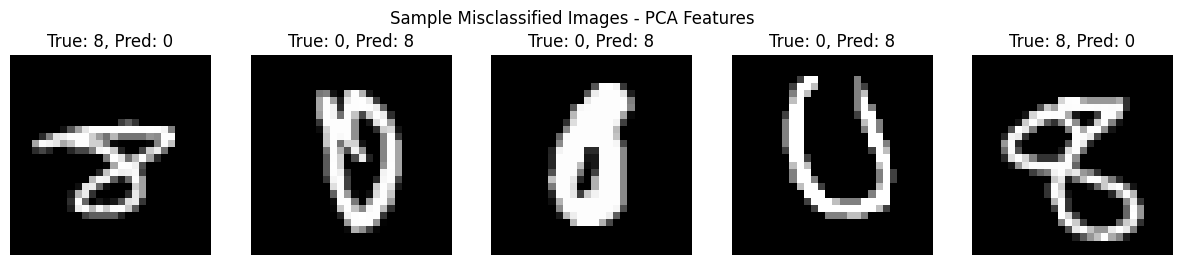

In [46]:
# For PCA 0.9
mis_idx_pca = np.where(y_pred_cv_pca != y_selected)[0]

print(f"Number of misclassifications (PCA): {len(mis_idx_pca)} / {len(y_selected)}")

if len(mis_idx_pca) > 0:
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, idx in enumerate(mis_idx_pca[:5]):
        axes[i].imshow(X_selected[idx].reshape(28, 28), cmap='gray')
        axes[i].set_title(f"True: {y_selected[idx]}, Pred: {y_pred_cv_pca[idx]}")
        axes[i].axis('off')
    plt.suptitle("Sample Misclassified Images - PCA Features")
    plt.show()